In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
dataset = pd.read_csv("../assets/csv-files/iris-flower.csv")
dataset.head(3)

,Sepal Length,Sepal Width,Petal Length,Petal Width,Species
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa


In [3]:
# Our data is labeled 
# For unsuperivised learning we need unlabeled data
# So lets remove Species column and make it unlabeled
dataset.drop(columns="Species", inplace=True)
dataset.head(3)

,Sepal Length,Sepal Width,Petal Length,Petal Width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2


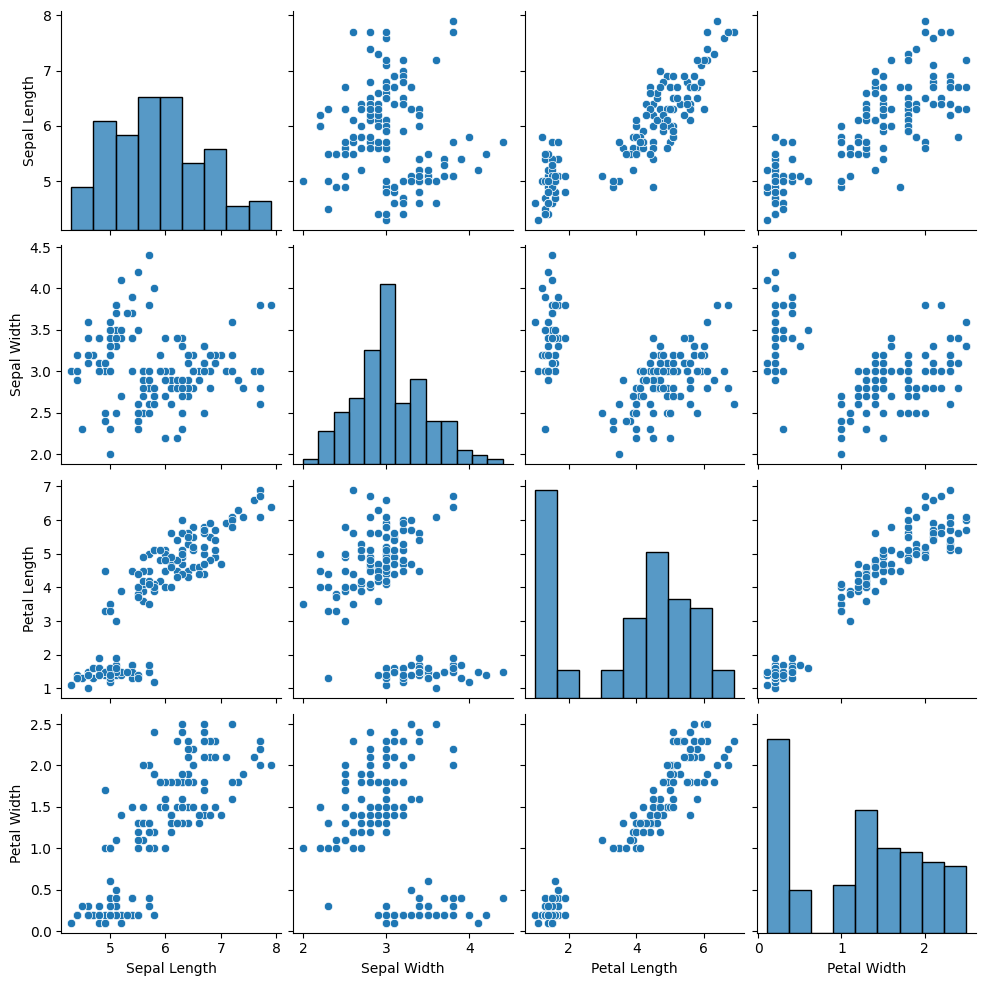

In [4]:
# Visualize the dataset
sns.pairplot(data=dataset)
plt.show()

In [5]:
# Find the best number of clusters
from sklearn.cluster import KMeans

In [6]:
wcss = []
for i in range(2, 21):
    km = KMeans(n_clusters=i, init="k-means++")
    # k-means++ improves the initialization of cluster centroids, which helps in achieving better clustering results and faster convergence
    km.fit(dataset)
    wcss.append(km.inertia_)  # Value of wcss

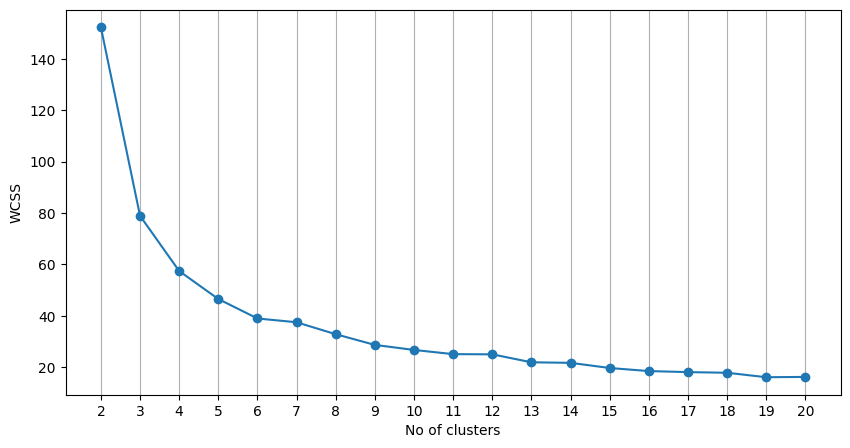

'3 is found to be elbow point'

In [7]:
# Draw an elbow graph
plt.figure(figsize=(10, 5))
plt.plot([i for i in range(2, 21)], wcss, marker="o")
plt.xlabel("No of clusters")
plt.xticks([i for i in range(2, 21)]) # List of positions at which to place the ticks
plt.ylabel("WCSS")
plt.grid(axis="x")
plt.show()
'''3 is found to be elbow point'''

In [8]:
# Make clusters with best value of k
kmn = KMeans(n_clusters=3)
kmn.fit_predict(dataset)

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 2, 2, 2, 1, 2, 2, 2,
       2, 2, 2, 1, 1, 2, 2, 2, 2, 1, 2, 1, 2, 1, 2, 2, 1, 1, 2, 2, 2, 2,
       2, 1, 2, 2, 2, 2, 1, 2, 2, 2, 1, 2, 2, 2, 1, 2, 2, 1], dtype=int32)

In [9]:
# Save the predicted value to dataset
dataset["Predict"] = kmn.fit_predict(dataset)
dataset.head(3)

,Sepal Length,Sepal Width,Petal Length,Petal Width,Predict
0,5.1,3.5,1.4,0.2,1
1,4.9,3.0,1.4,0.2,1
2,4.7,3.2,1.3,0.2,1


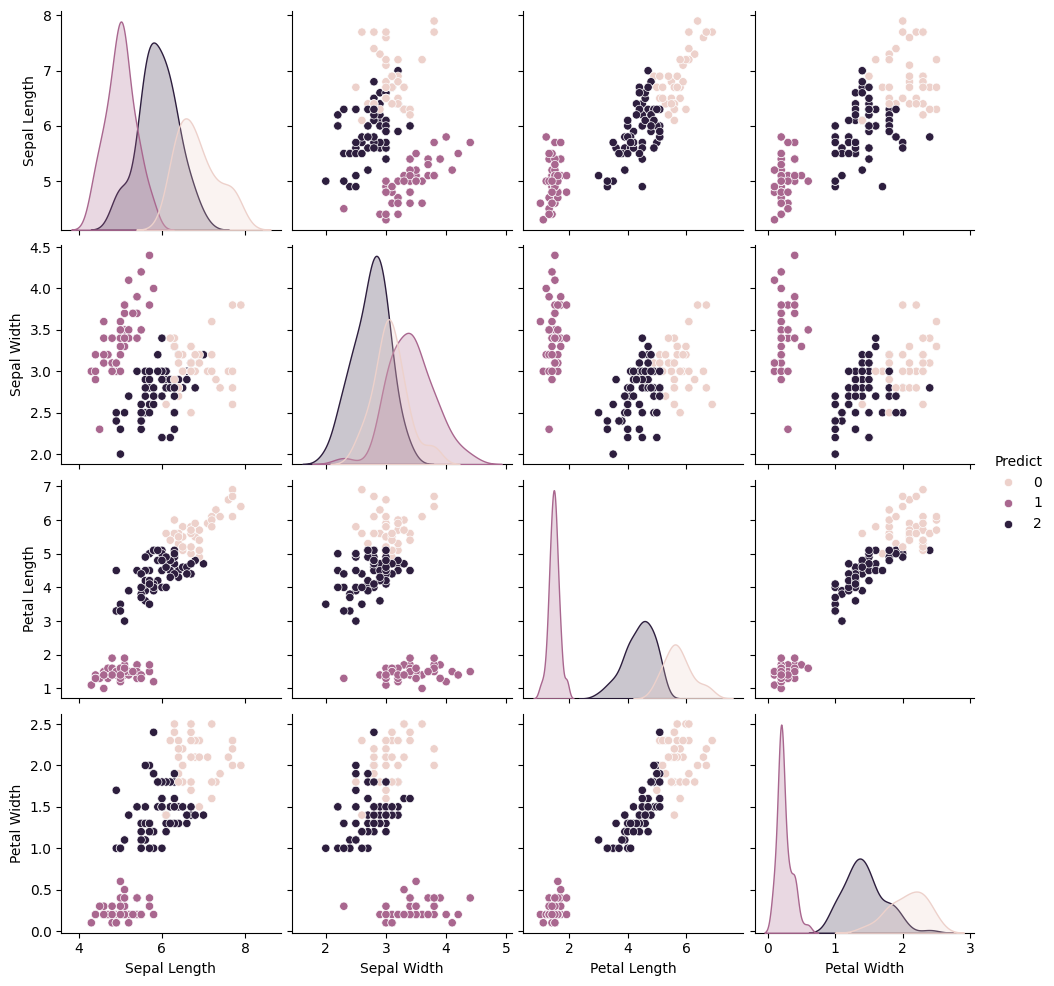

In [10]:
# Visualize the clusters
sns.pairplot(dataset, hue="Predict")
plt.show()